<a href="https://colab.research.google.com/github/tanvibeer12/Pattern-Recognition/blob/main/CM23020_PR_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

print("ZIP Extracted Successfully!")

ZIP Extracted Successfully!


In [ ]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["KMeans_Cluster"] = kmeans.fit_predict(X)

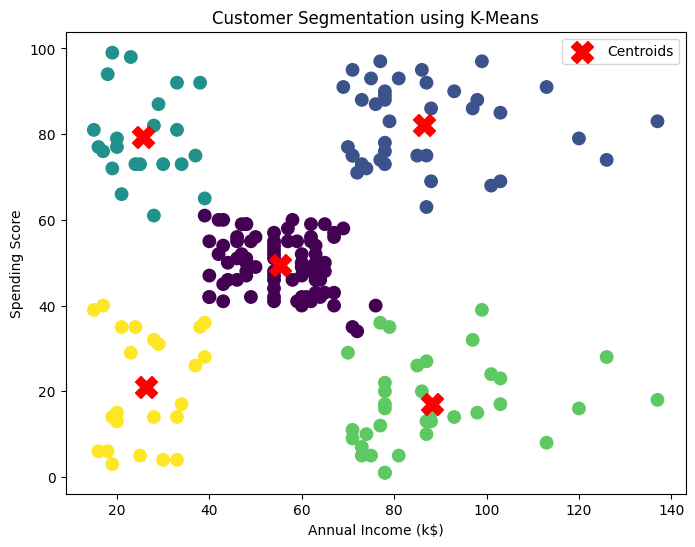

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

df["Hierarchical_Cluster"] = hierarchical.fit_predict(X)

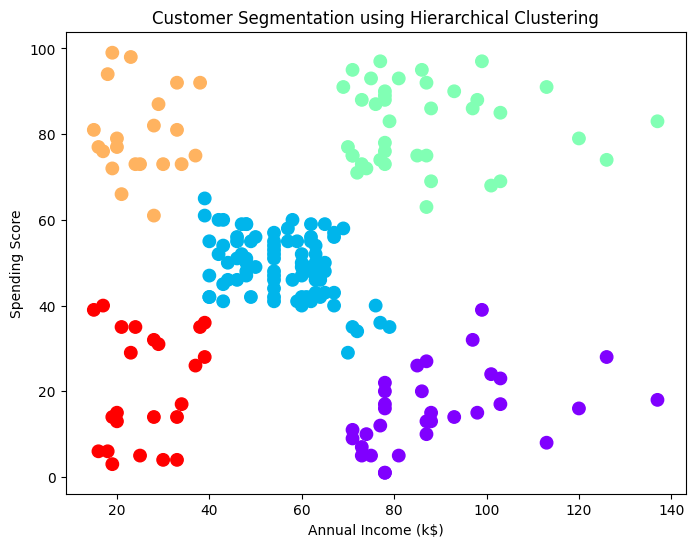

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df["Hierarchical_Cluster"],
    cmap="rainbow",
    s=80
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using Hierarchical Clustering")

plt.show()

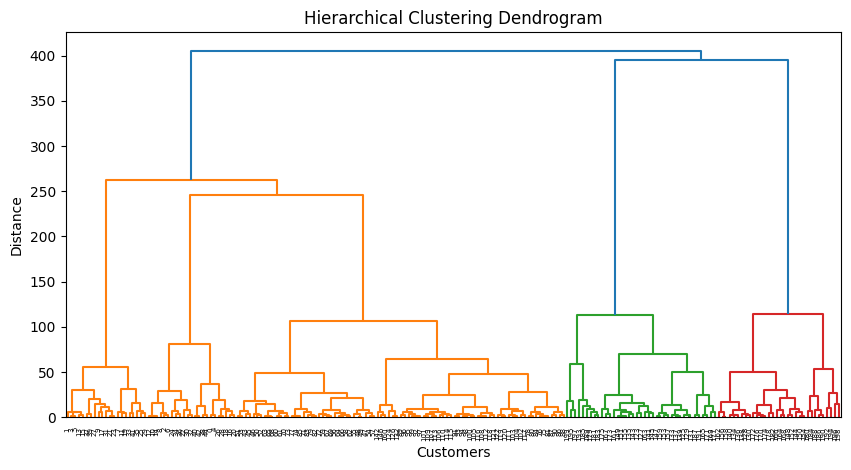

In [ ]:
plt.figure(figsize=(10,5))

linked = linkage(X, method="ward")

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [ ]:
print(df.groupby("KMeans_Cluster")[["Annual Income (k$)",
                                    "Spending Score (1-100)"]].mean())

                Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                            
0                        55.296296               49.518519
1                        86.538462               82.128205
2                        25.727273               79.363636
3                        88.200000               17.114286
4                        26.304348               20.913043


In [ ]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("Output Saved Successfully!")

Output Saved Successfully!
